In [13]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import time

# Plot Settings

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

pd.set_option("display.width", None)

print("="*70)
print("ALL LIBRARIES IMPORTED SUCCESSFULLY")
print("="*70)

ALL LIBRARIES IMPORTED SUCCESSFULLY


In [24]:
# ============================================================
# LOAD DATASET
# ============================================================

print("="*70)
print("LOADING DATASET")
print("="*70)
df = pd.read_csv(r"C:\Users\HARSH PATIL\Onedrive\Desktop\ML projects\Machine_learning_Projects\housepriceprediction\data.csv")

print("Dataset Loaded Successfully!")

print("\nDataset Shape")

print(df.shape)

print("\nFirst Five Rows")

display(df.head())

print("\nColumn Names")

for col in df.columns:
    print("•", col)

LOADING DATASET
Dataset Loaded Successfully!

Dataset Shape
(4600, 18)

First Five Rows


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA



Column Names
• date
• price
• bedrooms
• bathrooms
• sqft_living
• sqft_lot
• floors
• waterfront
• view
• condition
• sqft_above
• sqft_basement
• yr_built
• yr_renovated
• street
• city
• statezip
• country


In [32]:
# ============================================================
# DATASET INFORMATION
# ============================================================

print("="*70)
print("DATASET INFORMATION")
print("="*70)

print("\nRows :", df.shape[0])

print("Columns :", df.shape[1])

print("\nData Types")

display(df.dtypes)

print("\nDataset Info")

df.info()

print("\nStatistical Summary")

display(df.describe().T)

DATASET INFORMATION

Rows : 4600
Columns : 28

Data Types


price               float64
bedrooms            float64
bathrooms           float64
sqft_living           int64
sqft_lot              int64
floors              float64
waterfront            int64
view                  int64
condition             int64
sqft_above            int64
sqft_basement         int64
yr_built              int64
yr_renovated          int64
city                  int64
statezip                str
house_age             int64
is_renovated          int64
total_sqft            int64
living_ratio        float64
bath_per_bedroom    float64
has_basement          int64
total_rooms         float64
price_per_sqft      float64
build_decade          int64
luxury_house          int64
sale_year             int32
sale_month            int32
sale_day              int32
dtype: object


Dataset Info
<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             4600 non-null   float64
 1   bedrooms          4600 non-null   float64
 2   bathrooms         4600 non-null   float64
 3   sqft_living       4600 non-null   int64  
 4   sqft_lot          4600 non-null   int64  
 5   floors            4600 non-null   float64
 6   waterfront        4600 non-null   int64  
 7   view              4600 non-null   int64  
 8   condition         4600 non-null   int64  
 9   sqft_above        4600 non-null   int64  
 10  sqft_basement     4600 non-null   int64  
 11  yr_built          4600 non-null   int64  
 12  yr_renovated      4600 non-null   int64  
 13  city              4600 non-null   int64  
 14  statezip          4600 non-null   str    
 15  house_age         4600 non-null   int64  
 16  is_renovated      4600 non-null   int64

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.000000,322875.000000,460943.461539,654962.500000,2.659000e+07
bedrooms,4600.0,3.400870,0.908848,0.000000,3.000000,3.000000,4.000000,9.000000e+00
bathrooms,4600.0,2.160815,0.783781,0.000000,1.750000,2.250000,2.500000,8.000000e+00
sqft_living,4600.0,2139.346957,963.206916,370.000000,1460.000000,1980.000000,2620.000000,1.354000e+04
sqft_lot,4600.0,14852.516087,35884.436145,638.000000,5000.750000,7683.000000,11001.250000,1.074218e+06
floors,4600.0,1.512065,0.538288,1.000000,1.000000,1.500000,2.000000,3.500000e+00
waterfront,4600.0,0.007174,0.084404,0.000000,0.000000,0.000000,0.000000,1.000000e+00
view,4600.0,0.240652,0.778405,0.000000,0.000000,0.000000,0.000000,4.000000e+00
condition,4600.0,3.451739,0.677230,1.000000,3.000000,3.000000,4.000000,5.000000e+00
sqft_above,4600.0,1827.265435,862.168977,370.000000,1190.000000,1590.000000,2300.000000,9.410000e+03


In [33]:
# ============================================================
# MISSING VALUES & DUPLICATES
# ============================================================

print("="*70)
print("DATA QUALITY CHECK")
print("="*70)

missing = df.isnull().sum()

print("\nMissing Values")

display(missing)

print("\nTotal Missing Values :", missing.sum())

duplicates = df.duplicated().sum()

print("\nDuplicate Rows :", duplicates)

if duplicates > 0:

    df = df.drop_duplicates()

    print("Duplicate Rows Removed.")

else:

    print("No Duplicate Rows Found.")

DATA QUALITY CHECK

Missing Values


price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
city                0
statezip            0
house_age           0
is_renovated        0
total_sqft          0
living_ratio        0
bath_per_bedroom    0
has_basement        0
total_rooms         0
price_per_sqft      0
build_decade        0
luxury_house        0
sale_year           0
sale_month          0
sale_day            0
dtype: int64


Total Missing Values : 0

Duplicate Rows : 0
No Duplicate Rows Found.


TARGET VARIABLE ANALYSIS
count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64


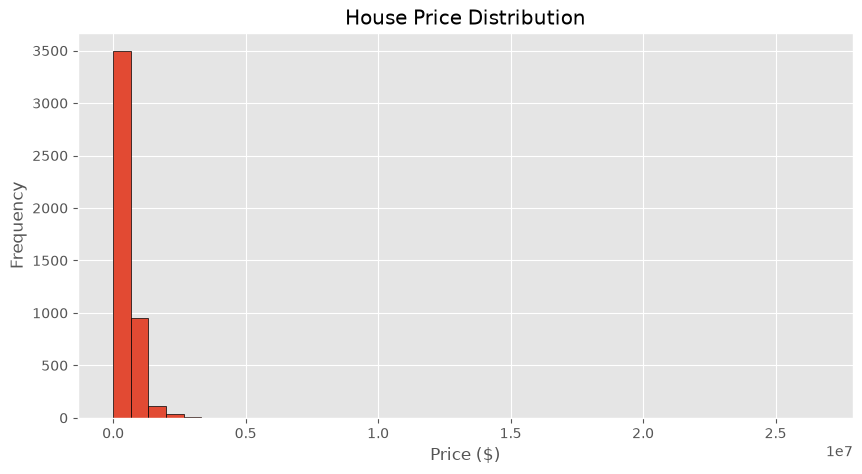

In [34]:
# ============================================================
# TARGET VARIABLE ANALYSIS
# ============================================================

print("="*70)
print("TARGET VARIABLE ANALYSIS")
print("="*70)

print(df["price"].describe())

plt.figure(figsize=(10,5))

plt.hist(
    df["price"],
    bins=40,
    edgecolor="black"
)

plt.title("House Price Distribution")

plt.xlabel("Price ($)")

plt.ylabel("Frequency")

plt.show()

In [35]:
# ============================================================
# CORRELATION ANALYSIS
# ============================================================

print("="*70)
print("CORRELATION ANALYSIS")
print("="*70)

numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

price_corr = correlation["price"].sort_values(ascending=False)

print("\nFeatures Correlated with House Price:\n")

display(price_corr)

print("\nTop 10 Features:")

display(price_corr.head(10))

CORRELATION ANALYSIS

Features Correlated with House Price:



price               1.000000
price_per_sqft      0.819399
total_sqft          0.430410
sqft_living         0.430410
sqft_above          0.367570
bathrooms           0.327110
total_rooms         0.294401
bath_per_bedroom    0.232612
view                0.228504
sqft_basement       0.210427
bedrooms            0.200336
luxury_house        0.181556
floors              0.151461
waterfront          0.135648
has_basement        0.110706
living_ratio        0.074701
sqft_lot            0.050451
sale_month          0.041081
condition           0.034915
build_decade        0.022916
yr_built            0.021857
city                0.018625
sale_day           -0.021544
house_age          -0.021857
is_renovated       -0.028595
yr_renovated       -0.028774
sale_year                NaN
Name: price, dtype: float64


Top 10 Features:


price               1.000000
price_per_sqft      0.819399
total_sqft          0.430410
sqft_living         0.430410
sqft_above          0.367570
bathrooms           0.327110
total_rooms         0.294401
bath_per_bedroom    0.232612
view                0.228504
sqft_basement       0.210427
Name: price, dtype: float64

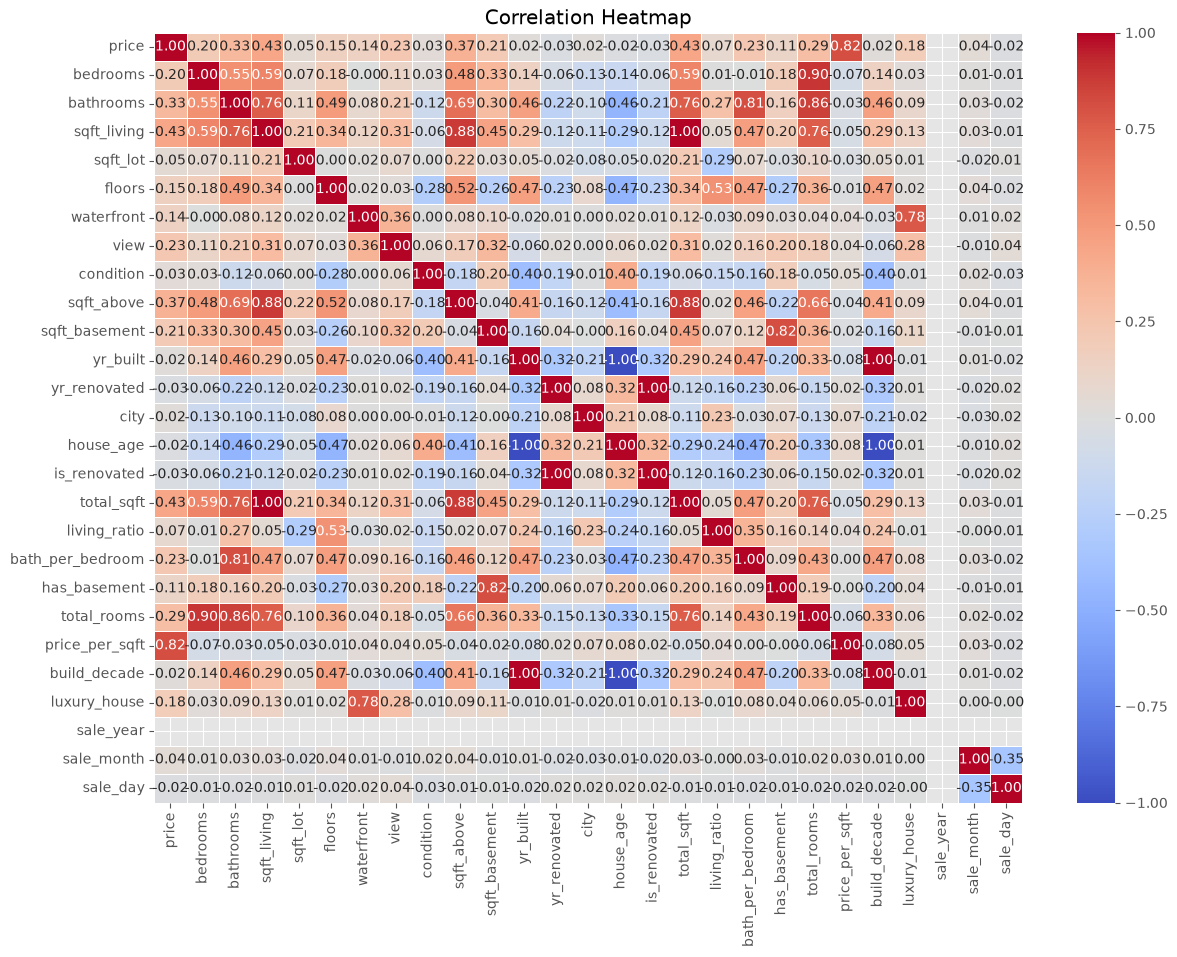

In [36]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

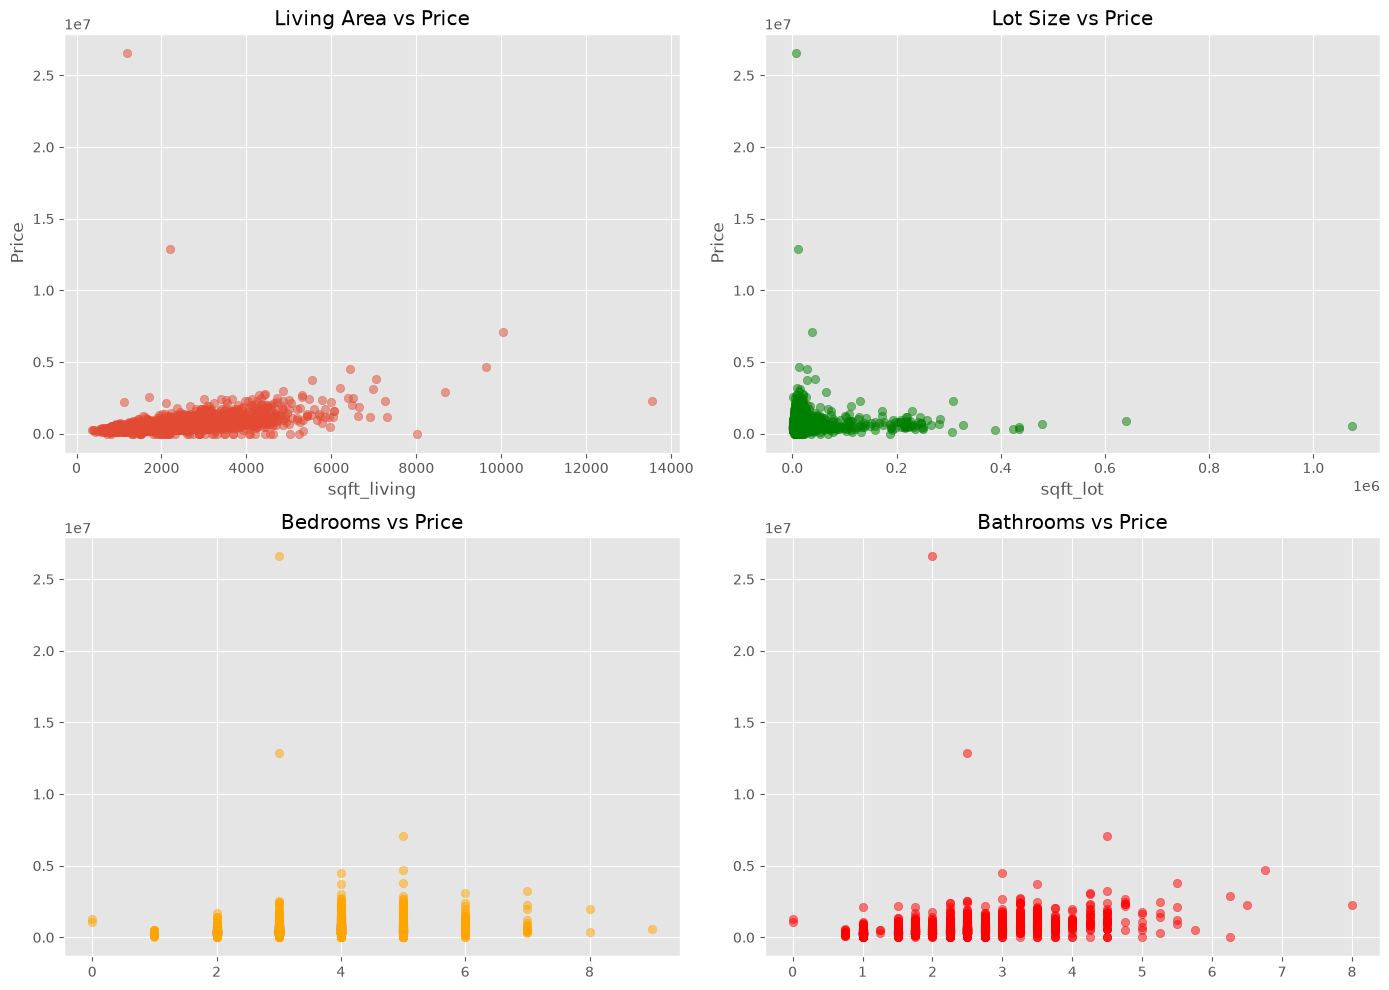

In [37]:
# ============================================================
# SCATTER PLOTS
# ============================================================

fig, axes = plt.subplots(2,2,figsize=(14,10))

# Living Area

axes[0,0].scatter(df["sqft_living"],df["price"],alpha=0.5)

axes[0,0].set_title("Living Area vs Price")

axes[0,0].set_xlabel("sqft_living")

axes[0,0].set_ylabel("Price")

# Lot Size

axes[0,1].scatter(df["sqft_lot"],df["price"],alpha=0.5,color="green")

axes[0,1].set_title("Lot Size vs Price")

axes[0,1].set_xlabel("sqft_lot")

axes[0,1].set_ylabel("Price")

# Bedrooms

axes[1,0].scatter(df["bedrooms"],df["price"],alpha=0.5,color="orange")

axes[1,0].set_title("Bedrooms vs Price")

# Bathrooms

axes[1,1].scatter(df["bathrooms"],df["price"],alpha=0.5,color="red")

axes[1,1].set_title("Bathrooms vs Price")

plt.tight_layout()

plt.show()

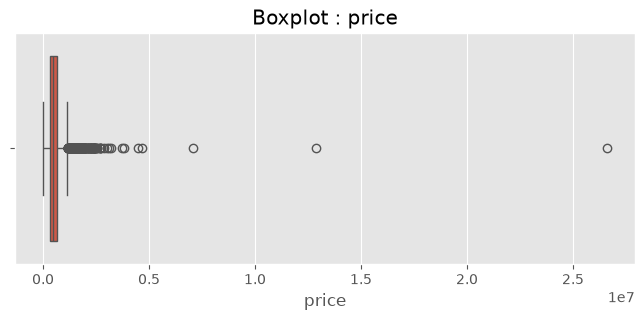

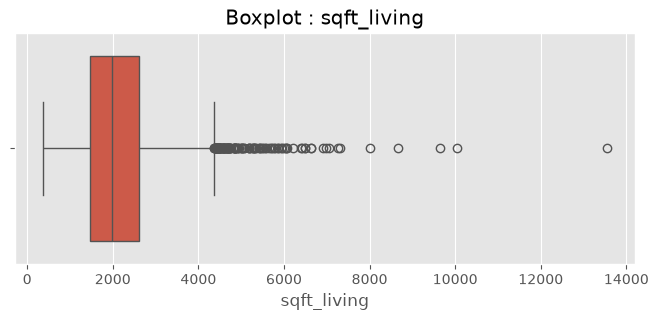

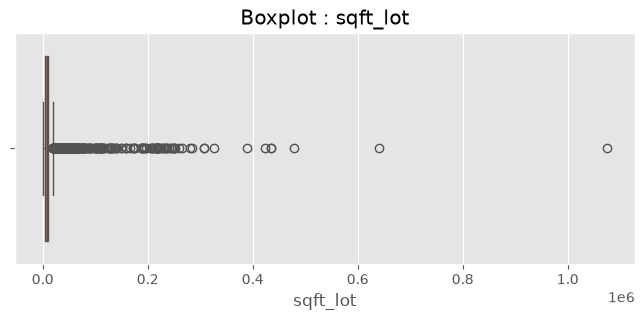

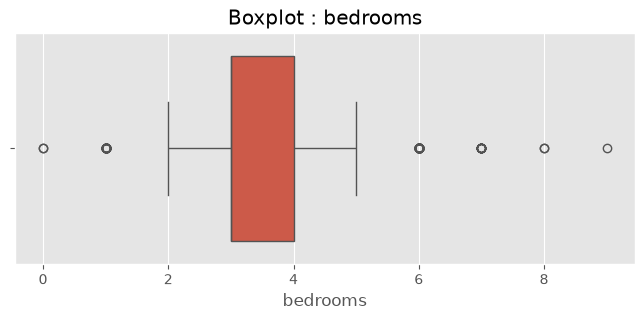

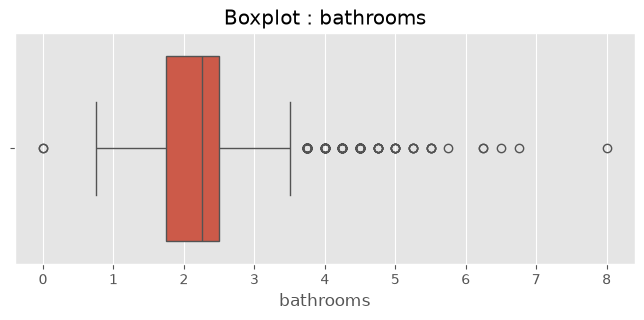

In [38]:
# ============================================================
# BOXPLOTS
# ============================================================

columns = [
    "price",
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms"
]

for col in columns:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot : {col}")

    plt.show()

In [39]:
# ============================================================
# CATEGORICAL ANALYSIS
# ============================================================

print("="*70)
print("CATEGORICAL FEATURES")
print("="*70)

print("\nTop Cities")

display(df["city"].value_counts().head(10))

print("\nWaterfront")

display(df["waterfront"].value_counts())

print("\nCondition")

display(df["condition"].value_counts())

CATEGORICAL FEATURES

Top Cities


city
35    1573
32     293
3      286
31     235
19     187
16     187
18     185
1      176
33     175
14     148
Name: count, dtype: int64


Waterfront


waterfront
0    4567
1      33
Name: count, dtype: int64


Condition


condition
3    2875
4    1252
5     435
2      32
1       6
Name: count, dtype: int64

In [40]:
# ============================================================
# EDA SUMMARY
# ============================================================

print("="*70)
print("EDA OBSERVATIONS")
print("="*70)

print("""
✔ Dataset Loaded Successfully

✔ Numerical Features Analysed

✔ Categorical Features Analysed

✔ Correlation Heatmap Generated

✔ Outliers Detected

✔ Scatter Plots Created

✔ Dataset Ready For Data Cleaning
""")

EDA OBSERVATIONS

✔ Dataset Loaded Successfully

✔ Numerical Features Analysed

✔ Categorical Features Analysed

✔ Correlation Heatmap Generated

✔ Outliers Detected

✔ Scatter Plots Created

✔ Dataset Ready For Data Cleaning



In [41]:
# ============================================================
# DATA CLEANING
# ============================================================

print("="*70)
print("DATA CLEANING")
print("="*70)

print("\nChecking Missing Values...\n")

display(df.isnull().sum())

print("\nRemoving Missing Values...")

df = df.dropna()

print("\nRemaining Missing Values")

display(df.isnull().sum())

print("\nDataset Shape")

print(df.shape)

DATA CLEANING

Checking Missing Values...



price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
city                0
statezip            0
house_age           0
is_renovated        0
total_sqft          0
living_ratio        0
bath_per_bedroom    0
has_basement        0
total_rooms         0
price_per_sqft      0
build_decade        0
luxury_house        0
sale_year           0
sale_month          0
sale_day            0
dtype: int64


Removing Missing Values...

Remaining Missing Values


price               0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront          0
view                0
condition           0
sqft_above          0
sqft_basement       0
yr_built            0
yr_renovated        0
city                0
statezip            0
house_age           0
is_renovated        0
total_sqft          0
living_ratio        0
bath_per_bedroom    0
has_basement        0
total_rooms         0
price_per_sqft      0
build_decade        0
luxury_house        0
sale_year           0
sale_month          0
sale_day            0
dtype: int64


Dataset Shape
(4600, 28)


In [42]:
# ============================================================
# REMOVE DUPLICATES
# ============================================================

duplicates = df.duplicated().sum()

print("Duplicate Rows :",duplicates)

if duplicates>0:

    df = df.drop_duplicates()

    print("Duplicates Removed")

else:

    print("Dataset Already Clean")

Duplicate Rows : 0
Dataset Already Clean


In [43]:
# ============================================================
# REMOVE OUTLIERS
# ============================================================

print("="*70)
print("OUTLIER REMOVAL")
print("="*70)

Q1 = df["price"].quantile(0.25)

Q3 = df["price"].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR

upper = Q3+1.5*IQR

before = len(df)

df = df[(df["price"]>=lower)&(df["price"]<=upper)]

after = len(df)

print("Rows Before :",before)

print("Rows After :",after)

print("Rows Removed :",before-after)

OUTLIER REMOVAL
Rows Before : 4600
Rows After : 4360
Rows Removed : 240


In [44]:
# ============================================================
# CLEANING SUMMARY
# ============================================================

print("="*70)
print("DATA CLEANING COMPLETED")
print("="*70)

print("""
✔ Missing Values Removed

✔ Duplicate Rows Removed

✔ Price Outliers Removed

Dataset Ready For Feature Engineering
""")

DATA CLEANING COMPLETED

✔ Missing Values Removed

✔ Duplicate Rows Removed

✔ Price Outliers Removed

Dataset Ready For Feature Engineering



In [45]:
# ============================================================
# FEATURE ENGINEERING - PART 1
# ============================================================

print("="*70)
print("FEATURE ENGINEERING - HOUSE AGE & RENOVATION")
print("="*70)

# Current Year
CURRENT_YEAR = 2024

# House Age
df["house_age"] = CURRENT_YEAR - df["yr_built"]

# Renovation Status
df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)

print("New Features Created")

print("✔ house_age")

print("✔ is_renovated")

print("\nPreview")

display(df[["yr_built",
            "yr_renovated",
            "house_age",
            "is_renovated"]].head())

FEATURE ENGINEERING - HOUSE AGE & RENOVATION
New Features Created
✔ house_age
✔ is_renovated

Preview


,yr_built,yr_renovated,house_age,is_renovated
0,1955,2005,69,1
2,1966,0,58,0
3,1963,0,61,0
4,1976,1992,48,1
5,1938,1994,86,1


In [46]:
# ============================================================
# FEATURE ENGINEERING - PART 4
# ============================================================

print("="*70)
print("LUXURY HOUSE FEATURE")
print("="*70)

price_threshold = df["price"].quantile(0.90)

df["luxury_house"] = (
    (df["waterfront"] == 1) &
    (df["view"] >= 3)
).astype(int)

print("Luxury Threshold Price")

print(price_threshold)

print("\nLuxury Houses")

print(df["luxury_house"].value_counts())

display(df[
[
"price",
"waterfront",
"view",
"luxury_house"
]
].head())

LUXURY HOUSE FEATURE
Luxury Threshold Price
799274.9999999999

Luxury Houses
luxury_house
0    4344
1      16
Name: count, dtype: int64


,price,waterfront,view,luxury_house
0,313000.0,0,0,0
2,342000.0,0,0,0
3,420000.0,0,0,0
4,550000.0,0,0,0
5,490000.0,0,0,0


ENGINEERED FEATURE CORRELATION


,house_age,is_renovated,total_sqft,has_basement,total_rooms,living_ratio,bath_per_bedroom,luxury_house,price
house_age,1.000000,0.320516,-0.334316,0.199916,-0.363104,-0.265293,-0.500010,0.015433,-0.061310
is_renovated,0.320516,1.000000,-0.138076,0.060397,-0.162561,-0.172657,-0.241541,-0.003883,-0.067996
total_sqft,-0.334316,-0.138076,1.000000,0.169412,0.750867,0.043795,0.428715,0.051726,0.579565
has_basement,0.199916,0.060397,0.169412,1.000000,0.168421,0.148209,0.065336,0.005922,0.145185
total_rooms,-0.363104,-0.162561,0.750867,0.168421,1.000000,0.138631,0.384641,0.008470,0.399919
living_ratio,-0.265293,-0.172657,0.043795,0.148209,0.138631,1.000000,0.362829,-0.044161,0.155867
bath_per_bedroom,-0.500010,-0.241541,0.428715,0.065336,0.384641,0.362829,1.000000,0.063002,0.310839
luxury_house,0.015433,-0.003883,0.051726,0.005922,0.008470,-0.044161,0.063002,1.000000,0.022060
price,-0.061310,-0.067996,0.579565,0.145185,0.399919,0.155867,0.310839,0.022060,1.000000


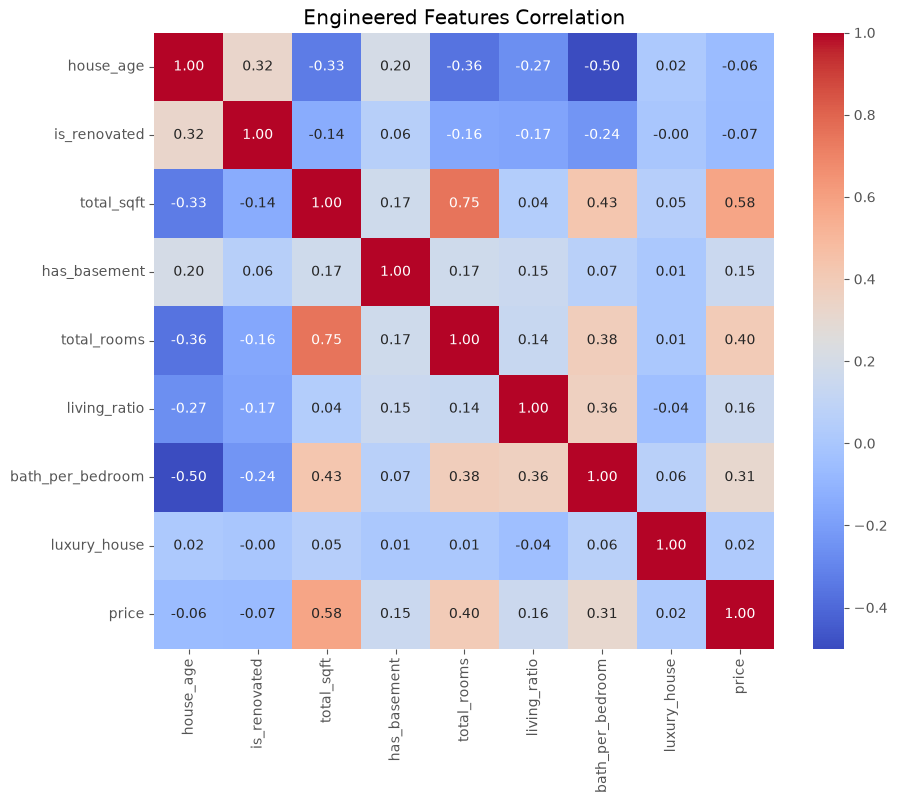

In [47]:
# ============================================================
# CORRELATION OF NEW FEATURES
# ============================================================

print("="*70)
print("ENGINEERED FEATURE CORRELATION")
print("="*70)

engineered = [

"house_age",

"is_renovated",

"total_sqft",

"has_basement",

"total_rooms",

"living_ratio",

"bath_per_bedroom",

"luxury_house",

"price"

]

corr = df[engineered].corr()

display(corr)

plt.figure(figsize=(10,8))

sns.heatmap(

corr,

annot=True,

cmap="coolwarm",

fmt=".2f"

)

plt.title("Engineered Features Correlation")

plt.show()

In [48]:
# ============================================================
# FEATURE ENGINEERING SUMMARY
# ============================================================

print("="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

new_features = [

"house_age",

"is_renovated",

"total_sqft",

"has_basement",

"total_rooms",

"living_ratio",

"bath_per_bedroom",

"luxury_house"

]

print("\nTotal New Features :", len(new_features))

print("\nFeature List")

for feature in new_features:

    print("✔", feature)

print("\nDataset Shape")

print(df.shape)

print("\nPreview")

display(df.head())

print("\nFeature Engineering Completed Successfully!")

FEATURE ENGINEERING SUMMARY

Total New Features : 8

Feature List
✔ house_age
✔ is_renovated
✔ total_sqft
✔ has_basement
✔ total_rooms
✔ living_ratio
✔ bath_per_bedroom
✔ luxury_house

Dataset Shape
(4360, 28)

Preview


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,house_age,is_renovated,total_sqft,living_ratio,bath_per_bedroom,has_basement,total_rooms,price_per_sqft,build_decade,luxury_house,sale_year,sale_month,sale_day
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,36,WA 98133,69,1,1340,0.169342,0.375000,0,4.50,233.407905,1950,0,2014,5,2
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,18,WA 98042,58,0,1930,0.161533,0.500000,0,5.00,177.110306,1960,0,2014,5,2
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,3,WA 98008,61,0,2000,0.249035,0.562500,1,5.25,209.895052,1960,0,2014,5,2
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,31,WA 98052,48,1,1940,0.184744,0.500000,1,6.50,283.359093,1970,0,2014,5,2
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,35,WA 98115,86,1,880,0.137909,0.333333,0,3.00,556.186152,1930,0,2014,5,2



Feature Engineering Completed Successfully!


In [53]:
# ============================================================
# FEATURE TRANSFORMATION - LABEL ENCODING
# ============================================================

print("=" * 70)
print("ENCODING CATEGORICAL FEATURES")
print("=" * 70)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_columns = [
    "city",
    "statezip"
]

for col in categorical_columns:

    df[col] = encoder.fit_transform(df[col])

    print(f"✔ {col} encoded successfully")

print("\nEncoded Columns Preview:")

display(df[categorical_columns].head())

print("\nEncoding Completed Successfully!")

ENCODING CATEGORICAL FEATURES
✔ city encoded successfully
✔ statezip encoded successfully

Encoded Columns Preview:


,city,statezip
0,36,62
2,18,26
3,3,7
4,31,31
5,35,54



Encoding Completed Successfully!


In [54]:
# ============================================================
# REMOVE UNNECESSARY FEATURES
# ============================================================

print("=" * 70)
print("REMOVING UNUSED COLUMNS")
print("=" * 70)

columns_to_drop = [

    "date",
    "street",
    "country"

]

# Drop only if they exist
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

df.drop(columns=columns_to_drop, inplace=True)

print("Dropped Columns:")

for col in columns_to_drop:
    print("✔", col)

print("\nRemaining Columns:", len(df.columns))

print("\nDataset Shape:", df.shape)

print("\nFirst Five Rows:")

display(df.head())

REMOVING UNUSED COLUMNS
Dropped Columns:

Remaining Columns: 28

Dataset Shape: (4360, 28)

First Five Rows:


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,house_age,is_renovated,total_sqft,living_ratio,bath_per_bedroom,has_basement,total_rooms,price_per_sqft,build_decade,luxury_house,sale_year,sale_month,sale_day
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,36,62,69,1,1340,0.169342,0.375000,0,4.50,233.407905,1950,0,2014,5,2
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,18,26,58,0,1930,0.161533,0.500000,0,5.00,177.110306,1960,0,2014,5,2
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,3,7,61,0,2000,0.249035,0.562500,1,5.25,209.895052,1960,0,2014,5,2
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,31,31,48,1,1940,0.184744,0.500000,1,6.50,283.359093,1970,0,2014,5,2
5,490000.0,2.0,1.00,880,6380,1.0,0,0,3,880,0,1938,1994,35,54,86,1,880,0.137909,0.333333,0,3.00,556.186152,1930,0,2014,5,2


In [55]:
# ============================================================
# FEATURE TRANSFORMATION SUMMARY
# ============================================================

print("=" * 70)
print("FEATURE TRANSFORMATION COMPLETED")
print("=" * 70)

print(f"Total Rows    : {df.shape[0]}")
print(f"Total Columns : {df.shape[1]}")

print("\nFinal Feature List:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i:2d}. {col}")

print("\nTransformation Steps Completed Successfully:")

print("""
✔ Date converted into datetime format
✔ Extracted sale_year
✔ Extracted sale_month
✔ Extracted sale_day
✔ Encoded city
✔ Encoded statezip
✔ Removed street
✔ Removed country
✔ Removed original date column

Dataset is now ready for:
➡ Train/Test Split
➡ Feature Scaling
➡ Machine Learning Models
""")

print("\nFeature Transformation Completed Successfully!")

FEATURE TRANSFORMATION COMPLETED
Total Rows    : 4360
Total Columns : 28

Final Feature List:

 1. price
 2. bedrooms
 3. bathrooms
 4. sqft_living
 5. sqft_lot
 6. floors
 7. waterfront
 8. view
 9. condition
10. sqft_above
11. sqft_basement
12. yr_built
13. yr_renovated
14. city
15. statezip
16. house_age
17. is_renovated
18. total_sqft
19. living_ratio
20. bath_per_bedroom
21. has_basement
22. total_rooms
23. price_per_sqft
24. build_decade
25. luxury_house
26. sale_year
27. sale_month
28. sale_day

Transformation Steps Completed Successfully:

✔ Date converted into datetime format
✔ Extracted sale_year
✔ Extracted sale_month
✔ Extracted sale_day
✔ Encoded city
✔ Encoded statezip
✔ Removed street
✔ Removed country
✔ Removed original date column

Dataset is now ready for:
➡ Train/Test Split
➡ Feature Scaling
➡ Machine Learning Models


Feature Transformation Completed Successfully!


In [56]:
# ============================================================
# STEP 7 : PREPARE FEATURES & TARGET
# ============================================================

print("=" * 70)
print("PREPARING FEATURES AND TARGET")
print("=" * 70)

# Target Variable
y = df["price"]

# Drop target column
X = df.drop(columns=["price"])

print("\nTarget Variable : price")

print("\nFeature Columns:\n")

for i, col in enumerate(X.columns, start=1):
    print(f"{i}. {col}")

print("\nTotal Features :", X.shape[1])

print("Total Samples  :", X.shape[0])

print("\nFeatures Shape :", X.shape)

print("Target Shape   :", y.shape)

print("\nFeature preparation completed successfully!")

PREPARING FEATURES AND TARGET

Target Variable : price

Feature Columns:

1. bedrooms
2. bathrooms
3. sqft_living
4. sqft_lot
5. floors
6. waterfront
7. view
8. condition
9. sqft_above
10. sqft_basement
11. yr_built
12. yr_renovated
13. city
14. statezip
15. house_age
16. is_renovated
17. total_sqft
18. living_ratio
19. bath_per_bedroom
20. has_basement
21. total_rooms
22. price_per_sqft
23. build_decade
24. luxury_house
25. sale_year
26. sale_month
27. sale_day

Total Features : 27
Total Samples  : 4360

Features Shape : (4360, 27)
Target Shape   : (4360,)

Feature preparation completed successfully!


In [57]:
# ============================================================
# TRAIN TEST SPLIT & FEATURE SCALING
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

print("\nScaling Features...")

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Scaling Completed Successfully!")

print("\nX_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

TRAIN TEST SPLIT
Training Samples : 3488
Testing Samples  : 872

Scaling Features...
Scaling Completed Successfully!

X_train Shape : (3488, 27)
X_test Shape  : (872, 27)


In [58]:
# ============================================================
# MODEL TRAINING
# ============================================================

print("=" * 70)
print("TRAINING MACHINE LEARNING MODELS")
print("=" * 70)

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.001),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

}

trained_models = {}

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    trained_models[name] = model

    print(f"{name} trained successfully!")

print("\nAll models trained successfully!")

TRAINING MACHINE LEARNING MODELS

Training Linear Regression...
Linear Regression trained successfully!

Training Ridge Regression...
Ridge Regression trained successfully!

Training Lasso Regression...
Lasso Regression trained successfully!

Training Decision Tree...
Decision Tree trained successfully!

Training Random Forest...
Random Forest trained successfully!

All models trained successfully!


In [59]:
# ============================================================
# RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================

from sklearn.model_selection import GridSearchCV

print("=" * 70)
print("RANDOM FOREST HYPERPARAMETER TUNING")
print("=" * 70)

param_grid = {

    "n_estimators": [100,200],

    "max_depth": [10,20,None],

    "min_samples_split": [2,5],

    "min_samples_leaf": [1,2]

}

grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    param_grid,

    cv=3,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

trained_models["Tuned Random Forest"] = best_rf

print("\nBest Parameters")

print(grid.best_params_)

print("\nBest Cross Validation Score")

print(grid.best_score_)

RANDOM FOREST HYPERPARAMETER TUNING

Best Parameters
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score
0.9939301980656183


In [60]:
# ============================================================
# MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

results = []

print("=" * 70)
print("MODEL EVALUATION")
print("=" * 70)

best_model = None
best_name = ""
best_r2 = -999

for name, model in trained_models.items():

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

    print("\n", "="*60)

    print(name)

    print("="*60)

    print(f"MAE  : ${mae:,.2f}")

    print(f"RMSE : ${rmse:,.2f}")

    print(f"R²   : {r2:.4f}")

    if r2 > best_r2:

        best_r2 = r2

        best_model = model

        best_name = name

results = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

results = results.sort_values(

    by="R2 Score",

    ascending=False

)

print("\n")

display(results)

print("\nBest Model :", best_name)

print("Best R² :", round(best_r2,4))

MODEL EVALUATION

Linear Regression
MAE  : $53,996.71
RMSE : $86,230.38
R²   : 0.8499

Ridge Regression
MAE  : $53,959.83
RMSE : $86,264.73
R²   : 0.8498

Lasso Regression
MAE  : $53,978.79
RMSE : $86,268.09
R²   : 0.8498

Decision Tree
MAE  : $16,354.15
RMSE : $28,804.18
R²   : 0.9833

Random Forest
MAE  : $7,170.57
RMSE : $18,059.53
R²   : 0.9934

Tuned Random Forest
MAE  : $7,177.52
RMSE : $18,116.25
R²   : 0.9934




,Model,MAE,RMSE,R2 Score
4,Random Forest,7170.567162,18059.531933,0.993418
5,Tuned Random Forest,7177.524122,18116.253988,0.993376
3,Decision Tree,16354.150739,28804.178438,0.983255
0,Linear Regression,53996.709915,86230.378382,0.849929
1,Ridge Regression,53959.834545,86264.733642,0.849809
2,Lasso Regression,53978.788289,86268.088255,0.849797



Best Model : Random Forest
Best R² : 0.9934


In [ ]:
# ============================================================
# SAVE MODEL
# ============================================================

import joblib

print("=" * 70)
print("SAVING MODEL")
print("=" * 70)

joblib.dump(best_model, "best_house_price_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("Best Model Saved Successfully!")

print("Scaler Saved Successfully!")

print("\nGenerated Files")

print("✔ best_house_price_model.pkl")

print("✔ scaler.pkl")

print("\nProject Completed Successfully!")